In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.datasets import make_classification

In [6]:
import sklearn.datasets

In [7]:
dir(sklearn.datasets)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_arff_parser',
 '_base',
 '_california_housing',
 '_covtype',
 '_kddcup99',
 '_lfw',
 '_olivetti_faces',
 '_openml',
 '_rcv1',
 '_samples_generator',
 '_species_distributions',
 '_svmlight_format_fast',
 '_svmlight_format_io',
 '_twenty_newsgroups',
 'clear_data_home',
 'dump_svmlight_file',
 'fetch_20newsgroups',
 'fetch_20newsgroups_vectorized',
 'fetch_california_housing',
 'fetch_covtype',
 'fetch_file',
 'fetch_kddcup99',
 'fetch_lfw_pairs',
 'fetch_lfw_people',
 'fetch_olivetti_faces',
 'fetch_openml',
 'fetch_rcv1',
 'fetch_species_distributions',
 'get_data_home',
 'load_breast_cancer',
 'load_diabetes',
 'load_digits',
 'load_files',
 'load_iris',
 'load_linnerud',
 'load_sample_image',
 'load_sample_images',
 'load_svmlight_file',
 'load_svmlight_files',
 'load_wine',
 'make_biclusters',
 'make_blobs',
 'make_checkerboard

In [8]:
?make_classification

Signature:
make_classification(
    n_samples=100,
    n_features=20,
    *,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=None,
    flip_y=0.01,
    class_sep=1.0,
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=None,
)
Docstring:
Generate a random n-class classification problem.

This initially creates clusters of points normally distributed (std=1)
about vertices of an ``n_informative``-dimensional hypercube with sides of
length ``2*class_sep`` and assigns an equal number of clusters to each
class. It introduces interdependence between these features and adds
various types of further noise to the data.

Without shuffling, ``X`` horizontally stacks features in the following
order: the primary ``n_informative`` features, followed by ``n_redundant``
linear combinations of the informative features, followed by ``n_repeated``
duplicates, drawn randomly with replacement from the infor

In [13]:
?pd.DataFrame

Init signature:
pd.DataFrame(
    data=None,
    index: 'Axes | None' = None,
    columns: 'Axes | None' = None,
    dtype: 'Dtype | None' = None,
    copy: 'bool | None' = None,
) -> 'None'
Docstring:     
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index. This alignment also
    occurs if data is a Series or a DataFrame itself. Alignment is done on
    Series/DataFrame inputs.

    If data is a list of dicts, column order follows 

0    0.984
1    0.016
Name: proportion, dtype: float64


<Axes: xlabel='varA', ylabel='varB'>

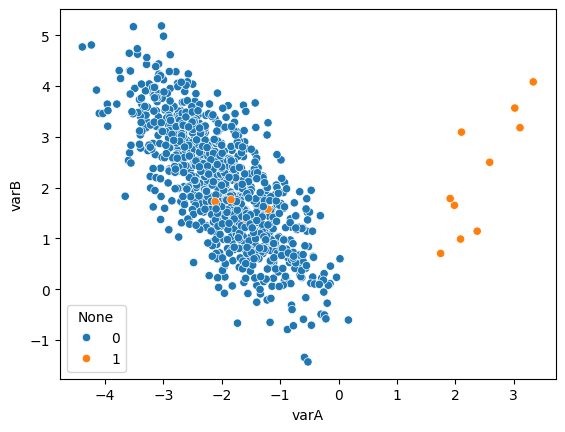

In [34]:
X, y =make_classification(n_samples=1000,
                          n_features=2,
                          n_redundant=0,
                          n_clusters_per_class=1,
                          weights=[0.99],
                          class_sep=2,
                          random_state=0)


X = pd.DataFrame(data=X, columns=['varA', 'varB'])
y = pd.Series(data=y)
print(y.value_counts(normalize=True))
sns.scatterplot(x='varA', y='varB', data=X, hue=y)

In [42]:
def make_data(sep):
    X, y =make_classification(n_samples=1000,
                          n_features=2,
                          n_redundant=0,
                          n_clusters_per_class=1,
                          weights=[0.99],
                          class_sep=sep,
                          random_state=0)


    X = pd.DataFrame(data=X, columns=['varA', 'varB'])
    y = pd.Series(data=y)
    print(y.value_counts(normalize=True))
    # sns.scatterplot(x='varA', y='varB', data=X, hue=y)

    return X, y


0    0.984
1    0.016
Name: proportion, dtype: float64


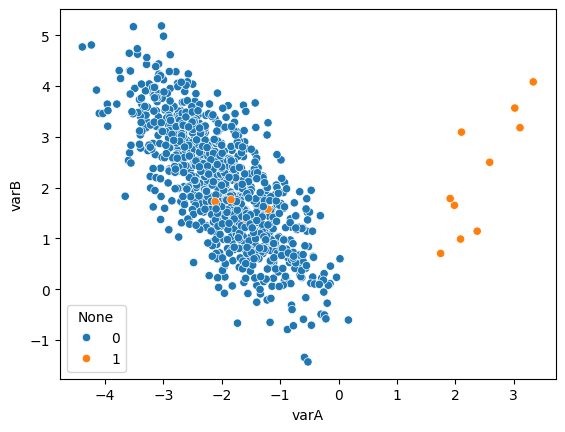

In [41]:
X,y = make_data(2)

0    0.984
1    0.016
Name: proportion, dtype: float64


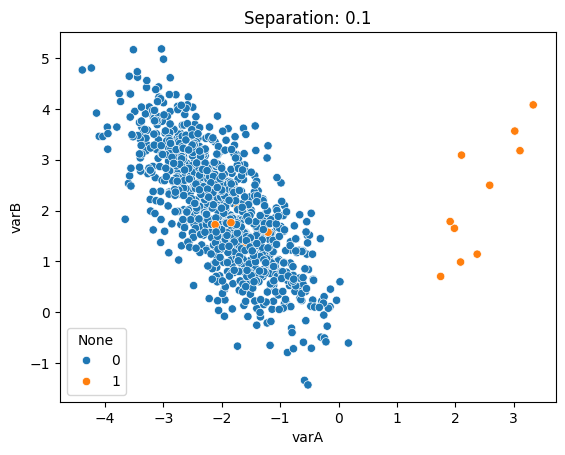

0    0.984
1    0.016
Name: proportion, dtype: float64


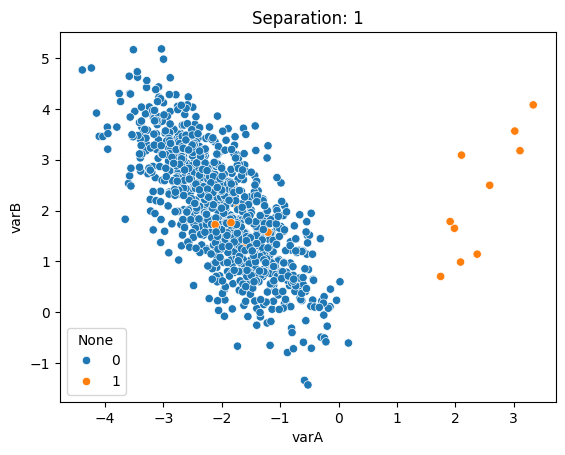

0    0.984
1    0.016
Name: proportion, dtype: float64


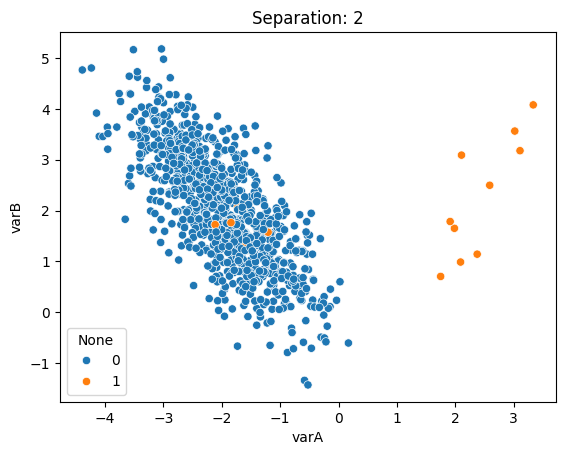

In [44]:
for sep in [0.1, 1, 2]:
    X, y = make_data(2)

    # print(y.value_counts(normalize=True))

    sns.scatterplot(data=X, x='varA', y='varB', hue=y)
    plt.title('Separation: {}'.format(sep))
    plt.show()

# Undersample with Condensed Nearest Neighbours

### Well separate classes

In [45]:
X, y = make_data(sep=2)

0    0.984
1    0.016
Name: proportion, dtype: float64


In [46]:
import imblearn

In [47]:
dir(imblearn)

['FunctionSampler',
 'LazyLoader',
 '__IMBLEARN_SETUP__',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_version',
 'base',
 'combine',
 'ensemble',
 'exceptions',
 'importlib',
 'keras',
 'metrics',
 'over_sampling',
 'pipeline',
 'show_versions',
 'sys',
 'tensorflow',
 'types',
 'under_sampling',
 'utils']

In [49]:
import imblearn.under_sampling

In [50]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [51]:
from imblearn.under_sampling import RandomUnderSampler

In [52]:
help(RandomUnderSampler)

Help on class RandomUnderSampler in module imblearn.under_sampling._prototype_selection._random_under_sampler:

class RandomUnderSampler(imblearn.under_sampling.base.BaseUnderSampler)
 |  RandomUnderSampler(*, sampling_strategy='auto', random_state=None, replacement=False)
 |  
 |  Class to perform random under-sampling.
 |  
 |  Under-sample the majority class(es) by randomly picking samples
 |  with or without replacement.
 |  
 |  Read more in the :ref:`User Guide <controlled_under_sampling>`.
 |  
 |  Parameters
 |  ----------
 |  sampling_strategy : float, str, dict, callable, default='auto'
 |      Sampling information to sample the data set.
 |  
 |      - When ``float``, it corresponds to the desired ratio of the number of
 |        samples in the minority class over the number of samples in the
 |        majority class after resampling. Therefore, the ratio is expressed as
 |        :math:`\alpha_{us} = N_{m} / N_{rM}` where :math:`N_{m}` is the
 |        number of samples in 